In [39]:
from os import mkdir

import pandas as pd
import seaborn as sns
from data_profiling import ProfileReport
import matplotlib.pyplot as plt
from pathlib import Path

# ROOT = Path(__file__).resolve().parent.parent # makhdamach f notbook\

ROOT = Path.cwd().parent

In [40]:
%matplotlib inline

In [41]:
def load_data():
    return pd.read_csv(ROOT / "data/raw/dataset.csv")

df = load_data()

In [42]:
def make_profiling(df: pd.DataFrame):

    REPORT_PATH = ROOT / "Report" / "eda_report.html"
    REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

    profile = ProfileReport(df, title="Profiling Report")
    profile.to_file(REPORT_PATH)

In [43]:
def get_discription(df: pd.DataFrame):
    return df.describe()

In [44]:
def describe__all(df: pd.DataFrame):
    df.describe()
    df.describe(include="object")
    df.info()
    df.head()
    df.isna().sum()

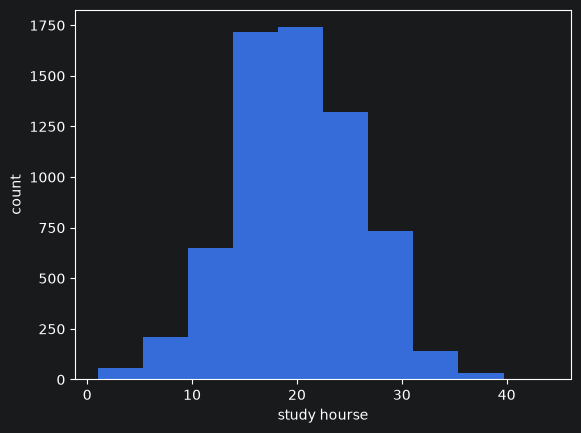

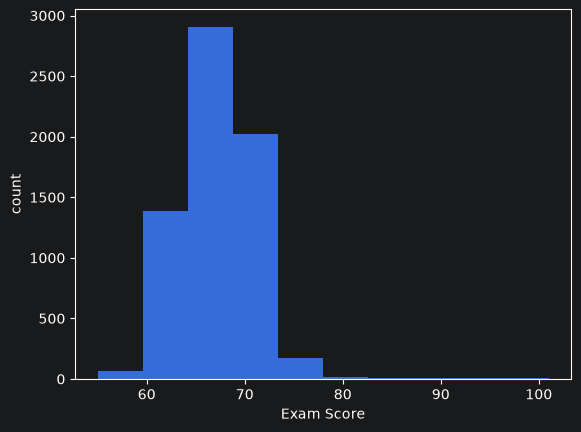

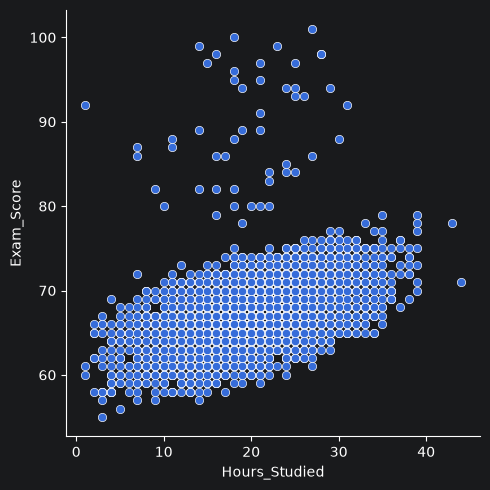

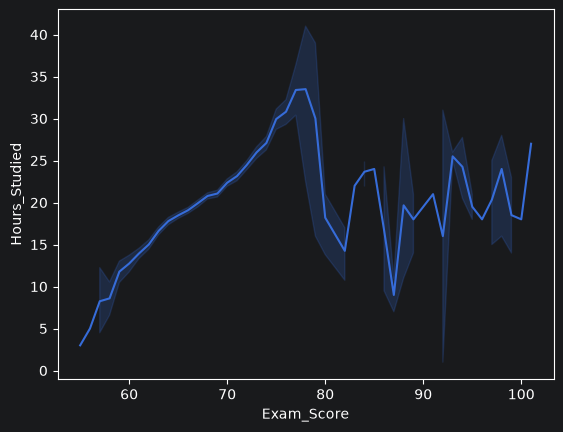

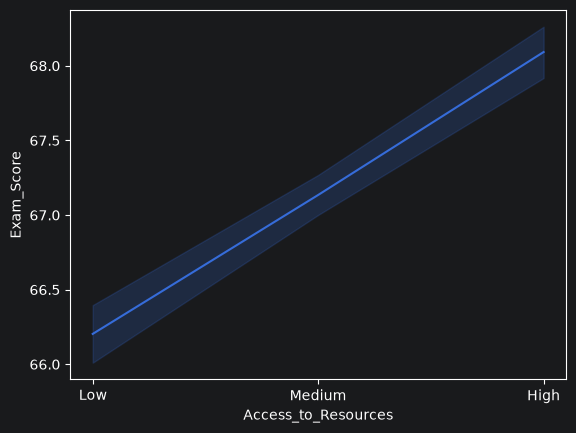

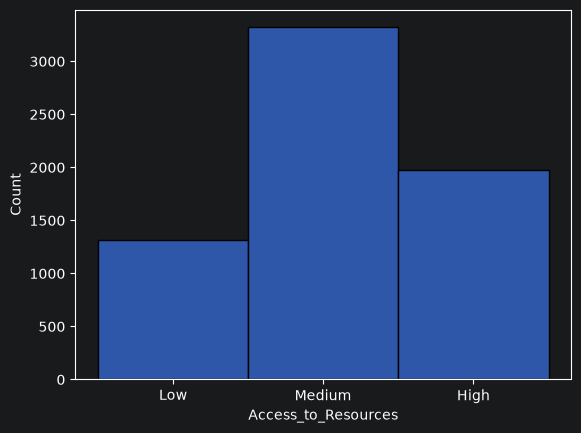

In [49]:
def view_study_hours(df: pd.DataFrame):
    df['Hours_Studied'].plot(kind="hist", xlabel="study hourse", ylabel="count")
    plt.show()
    df['Exam_Score'].plot(kind="hist", xlabel="Exam Score", ylabel="count")
    plt.show()
    sns.relplot(data=df, x="Hours_Studied", y="Exam_Score")
    plt.show()
    sns.lineplot(data=df, y="Hours_Studied", x="Exam_Score")
    plt.show()

    df["Access_to_Resources"] = pd.Categorical(
        df["Access_to_Resources"],
        categories=["Low", "Medium", "High"],
        ordered=True
    )

    sns.lineplot(data=df, x="Access_to_Resources", y="Exam_Score")
    plt.show()

    sns.histplot(data=df['Access_to_Resources'])
    plt.show()
view_study_hours(df)

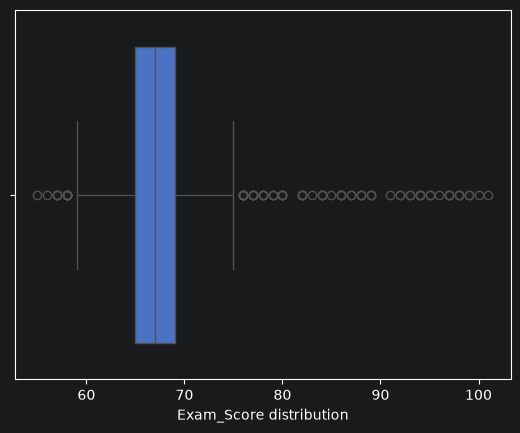

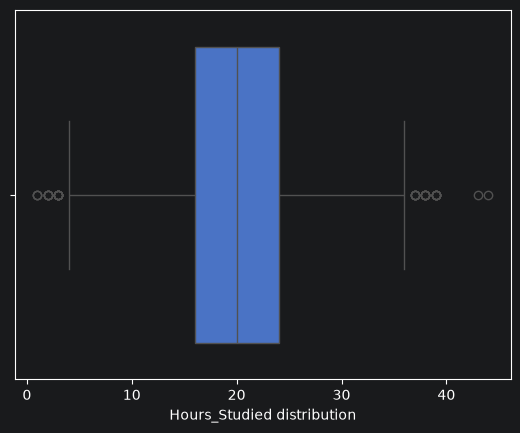

In [46]:
def see_distribution(df: pd.DataFrame, col):
  sns.boxplot(x = df[col])
  plt.xlabel(f'{col} distribution')
  plt.show()

for col in ["Exam_Score", "Hours_Studied"]:
  see_distribution(df, col)

In [47]:
def find_outliers(df: pd.DataFrame, col):
  Q1, Q3 = df[col].quantile([0.25, 0.75])
  IQR = Q3 - Q1
  MIN_VALUE = Q1 - 1.5 * IQR
  MAX_VALUE = Q3 + 1.5 * IQR
  mask = (df[col] < MIN_VALUE) | (df[col] > MAX_VALUE)
  outliers = df[mask]
  return len(outliers), outliers, IQR, Q1, Q3

outlier_count, outliers, IQR, Q1, Q3 = find_outliers(df, 'Exam_Score')
outliers

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
106,31,100,Medium,Medium,No,7,59,Medium,Yes,2,High,High,Public,Positive,5,No,Postgraduate,Moderate,Male,76
113,35,99,High,High,Yes,7,85,Low,Yes,2,Medium,High,Private,Neutral,2,No,Postgraduate,Near,Female,79
209,43,86,High,Medium,Yes,7,97,Medium,Yes,2,Medium,High,Public,Positive,1,No,High School,Near,Female,78
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6347,28,96,High,Low,Yes,4,98,High,Yes,1,High,High,Public,Positive,3,No,High School,Near,Male,98
6393,16,83,Low,Medium,Yes,8,92,Low,Yes,2,High,High,Public,Positive,4,No,Postgraduate,Near,Female,98
6431,4,60,Medium,Medium,Yes,7,55,Medium,Yes,2,Low,Medium,Private,Neutral,2,No,Postgraduate,Near,Male,58
6522,18,90,High,High,Yes,6,54,Low,Yes,1,Medium,High,Public,Negative,3,No,High School,Near,Female,95


In [50]:
def calclulate_z_score(df: pd.DataFrame, column: str):
  z = (df[column] - df[column].mean()) / df[column].std()
  return df[z.abs() > 3]
calclulate_z_score(df, "Exam_Score")

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
113,35,99,High,High,Yes,7,85,Low,Yes,2,Medium,High,Private,Neutral,2,No,Postgraduate,Near,Female,79
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89
404,17,77,Low,High,Yes,5,53,Medium,Yes,2,High,Medium,Public,Neutral,3,No,College,Near,Male,86
529,15,83,Medium,Medium,No,7,97,Medium,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Female,97
558,22,70,Low,Medium,No,7,53,Low,Yes,1,Low,Medium,Public,Positive,3,No,High School,Near,Female,83
560,22,71,Low,High,Yes,9,56,High,Yes,1,Low,High,Public,Neutral,3,Yes,College,Near,Female,84
637,20,65,Medium,Low,Yes,7,62,High,Yes,0,Medium,Medium,Public,Neutral,0,Yes,Postgraduate,Near,Male,80
770,24,96,Low,High,No,6,93,Medium,Yes,2,Low,Medium,Public,Neutral,2,No,High School,Moderate,Female,94
836,29,76,Medium,Medium,No,8,96,Low,Yes,2,Low,Medium,Public,Positive,2,No,Postgraduate,Moderate,Male,94


In [ ]:
def find_outliers(df: pd.DataFrame, col):
  Q1, Q3 = df[col].quantile([0.25, 0.75])
  IQR = Q3 - Q1
  MIN_VALUE = Q1 - 1.5 * IQR
  MAX_VALUE = Q3 + 1.5 * IQR
  mask = (df[col] < MIN_VALUE) | (df[col] > MAX_VALUE)
  outliers = df[mask]
  return len(outliers), outliers, IQR, Q1, Q3, mask

outlier_count, outliers, IQR, Q1, Q3, outliers_mask = find_outliers(df, 'Exam_Score')
outliers